# Cognition & Computation - Lab 2

As usual, let's first download the scripts from the GitHub repository that implement a DBN in PyTorch, and load some useful Python libraries.

In [1]:
def get_dbn_library():
  files = ["DBN.py", "RBM.py"]
  repository_url = "https://raw.githubusercontent.com/flavio2018/Deep-Belief-Network-pytorch/master/"
  for file in files:
    ! wget -O {file} {repository_url}{file}

In [2]:
%%capture
get_dbn_library()

In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision as tv

from DBN import DBN

Let's choose the kind of device used for computations (CPU or GPU).

In [4]:
print(torch.cuda.is_available())
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

True
cuda


Let's download and normalize the MNIST dataset as in the previous Lab.

In [5]:
%%capture
mnist_tr = tv.datasets.MNIST(root="../mnist", train=True, download=True) # IT'S A dataset
mnist_te = tv.datasets.MNIST(root="../mnist", train=False, download=True)

In [6]:
mnist_tr.data = mnist_tr.data / 255
mnist_te.data = mnist_te.data / 255

mnist_tr.data = mnist_tr.data.to(device)
mnist_te.data = mnist_te.data.to(device)
mnist_tr.targets = mnist_tr.targets.to(device)
mnist_te.targets = mnist_te.targets.to(device)

We now create a hierarchical generative model (Deep Belief Network) and train it in an unsupervised way on the MNIST dataset.

In [8]:
dbn_mnist = DBN(visible_units=28*28,   # we define hierical structure of model
                hidden_units=[400, 500, 800],   # try to be better than how it's made her for the project
                k=1,
                learning_rate=0.1,
                learning_rate_decay=False,
                initial_momentum=0.5,
                final_momentum=0.95,
                weight_decay=0.0001,
                xavier_init=False,
                increase_to_cd_k=False,
                use_gpu=torch.cuda.is_available())

In [9]:
num_epochs = 50
batch_size = 125

 # it's important thet construction error should decrease, otherwise we don't properly initialize wieghts or other things
dbn_mnist.train_static(
    mnist_tr.data,
    mnist_tr.targets,
    num_epochs,
    batch_size
)

# we try to sistematically inject the level of noise in order to see how the accuracy changes
# it shows the example of the theory slide on deep generative models for noise injection  ( slide 7 e 15  ). We just focus on gaussian noise
# it's possible to add adversarial noise

--------------------
Training RBM layer 1
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.2088     |0.0594       |304.1000   |7.6357     |
|20    |1.1199     |0.0533       |280.5635   |6.7140     |
|30    |1.0970     |0.0534       |273.7027   |8.6954     |
|40    |1.0860     |0.0504       |270.9075   |6.4527     |
|50    |1.0783     |0.0492       |268.2816   |6.7259     |
--------------------
Training RBM layer 2
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.6715     |0.0611       |228.2470   |4.7890     |
|20    |1.5364     |0.0531       |216.6104   |4.0833     |
|30    |1.5078     |0.0536       |213.4731   |4.5592     |
|40    |1.4942     |0.0527       |211.6138   |4.3959     |
|50    |1.4924     |0.0507       |211.8326   |4.5912     |
--------------------
Training RBM layer 3
|Epoch |avg_rec_err |std_rec_err  |mean_grad |std_grad  |
|10    |1.1273     |0.0452       |270.9308   |5.3039     |
|20    |1.0088     |0.0381       |252.8956   |4.927

## Linear read-out

As in the previous lab, we extract the hidden representations of the data, by propagating the neuron's activations from the sensory (visible) layer in a bottom-up fashion, and try to lineary decode the content of the representations in a supervised way.

In [10]:
def get_kth_layer_repr(input, k, device):
  flattened_input = input.view((input.shape[0], -1)).type(torch.FloatTensor).to(device)
  hidden_repr, __ = dbn_mnist.rbm_layers[k].to_hidden(flattened_input)  # here we access the RBM object
  return hidden_repr

In [11]:
hidden_repr_1 = get_kth_layer_repr(mnist_tr.data, 0, device) # we save the activation of first hidden layer
hidden_repr_2 = get_kth_layer_repr(hidden_repr_1, 1, device) #same for second
hidden_repr_3 = get_kth_layer_repr(hidden_repr_2, 2, device)# same for third

In [12]:
class LinearModel(torch.nn.Module):
  def __init__(self, last_layer_size):
    super().__init__()
    self.linear = torch.nn.Linear(last_layer_size, 10)

  def forward(self, x):
    return self.linear(x)

In [13]:
layer_size = dbn_mnist.rbm_layers[0].W.shape[1]
linear1 = LinearModel(layer_size).to(device)

layer_size = dbn_mnist.rbm_layers[1].W.shape[1]
linear2 = LinearModel(layer_size).to(device)

layer_size = dbn_mnist.rbm_layers[2].W.shape[1]
linear3 = LinearModel(layer_size).to(device)

In [14]:
def train_supervised(network, input_data, epochs=1000):  #network( each linear classifier)
  optimizer = torch.optim.SGD(network.parameters(), lr=0.05) #sgd= stochastic gradient descent
  loss_fn = torch.nn.CrossEntropyLoss()

  for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = network(input_data).squeeze()
    targets = mnist_tr.targets.reshape(predictions.shape[0])  # here are the labels
    loss = loss_fn(predictions, targets)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
      print("epoch : {:3d}/{}, loss = {:.4f}".format(epoch + 1, epochs, loss))
      #linear classifier is much faster than hierical method
      #also here, the most important thing is that error decrease

In [15]:
train_supervised(linear1, hidden_repr_1, 1000)
train_supervised(linear2, hidden_repr_2, 1000)
train_supervised(linear3, hidden_repr_3, 1000)

epoch :   1/1000, loss = 2.2997
epoch : 101/1000, loss = 0.7596
epoch : 201/1000, loss = 0.5378
epoch : 301/1000, loss = 0.4490
epoch : 401/1000, loss = 0.3992
epoch : 501/1000, loss = 0.3664
epoch : 601/1000, loss = 0.3426
epoch : 701/1000, loss = 0.3244
epoch : 801/1000, loss = 0.3097
epoch : 901/1000, loss = 0.2976
epoch :   1/1000, loss = 2.3421
epoch : 101/1000, loss = 0.7609
epoch : 201/1000, loss = 0.5438
epoch : 301/1000, loss = 0.4564
epoch : 401/1000, loss = 0.4070
epoch : 501/1000, loss = 0.3743
epoch : 601/1000, loss = 0.3506
epoch : 701/1000, loss = 0.3324
epoch : 801/1000, loss = 0.3177
epoch : 901/1000, loss = 0.3056
epoch :   1/1000, loss = 2.2754
epoch : 101/1000, loss = 0.7129
epoch : 201/1000, loss = 0.4926
epoch : 301/1000, loss = 0.4057
epoch : 401/1000, loss = 0.3572
epoch : 501/1000, loss = 0.3255
epoch : 601/1000, loss = 0.3027
epoch : 701/1000, loss = 0.2852
epoch : 801/1000, loss = 0.2712
epoch : 901/1000, loss = 0.2597


In [16]:
hidden_repr_1_test = get_kth_layer_repr(mnist_te.data, 0, device)
hidden_repr_2_test = get_kth_layer_repr(hidden_repr_1_test, 1, device)
hidden_repr_3_test = get_kth_layer_repr(hidden_repr_2_test, 2, device)

In [17]:
# compute the classifier predictions:
predictions_test1 = linear1(hidden_repr_1_test)
predictions_test2 = linear2(hidden_repr_2_test)
predictions_test3 = linear3(hidden_repr_3_test)

In [18]:
def compute_accuracy(predictions_test, targets):
  predictions_indices = predictions_test.max(axis=1).indices  # convert probabilities to indices
  accuracy = (predictions_indices == targets).sum() / len(targets)
  return accuracy.item()

In [19]:
compute_accuracy(predictions_test1, mnist_te.targets)

0.9319999814033508

In [20]:
compute_accuracy(predictions_test2, mnist_te.targets)

0.9307999610900879

In [21]:
compute_accuracy(predictions_test3, mnist_te.targets) # we slighty increase as we move on gerarchical model

0.9407999515533447

## Comparison with a feed-forward neural network

Let's now train a simple feed-forward neural network with the same structure of the DBN, in order to compare a non-linear model that is trained end-to-end to solve a classification task with a simple linear classifier that solves the same task using representations of input data learned in an unsupervised way through the DBN.

will be less tolerant noise, compared to hierical?

In [22]:
class Feedforward(torch.nn.Module):
  def __init__(self, first_hidden_layer_size, second_hidden_layer_size, third_hidden_layer_size):
    super().__init__()
    self.first_hidden = torch.nn.Linear(784, first_hidden_layer_size)
    self.second_hidden = torch.nn.Linear(first_hidden_layer_size, second_hidden_layer_size)
    self.third_hidden = torch.nn.Linear(second_hidden_layer_size, third_hidden_layer_size)
    self.output = torch.nn.Linear(third_hidden_layer_size, 10) # final layer corresponding to the classification task

  def forward(self, input):
    relu = torch.nn.ReLU() # this is very simple feedforward neural network. here we use relu activation funct.
    first_hidden_repr = relu(self.first_hidden(input))
    second_hidden_repr = relu(self.second_hidden(first_hidden_repr))
    third_hidden_repr = relu(self.third_hidden(second_hidden_repr))
    output = self.output(third_hidden_repr)
    return output

In [23]:
ffnn = Feedforward(400, 500, 800).to(device) #

for our porject we can use different libraries. we can also use different things compared to SGD, like adam-optimizer ecc

In [24]:
train_supervised(ffnn, mnist_tr.data.reshape((60000, 784)), 1050) # we want a number of epoch of before, the difference here is that we have supervised learning all the time

epoch :   1/1050, loss = 2.3014
epoch : 101/1050, loss = 2.1730
epoch : 201/1050, loss = 0.9679
epoch : 301/1050, loss = 0.5455
epoch : 401/1050, loss = 0.4294
epoch : 501/1050, loss = 0.3761
epoch : 601/1050, loss = 0.3440
epoch : 701/1050, loss = 0.3204
epoch : 801/1050, loss = 0.3009
epoch : 901/1050, loss = 0.2840
epoch : 1001/1050, loss = 0.2688


In [25]:
predictions_ffnn = ffnn(mnist_te.data.reshape((10000, 784)))

In [26]:
compute_accuracy(predictions_ffnn, mnist_te.targets) # he descrive this situation like the page 7 in the first point, before injections

0.9269999861717224

## Robustness to noise

We will now inject some noise in the input images and see how much the representations learned by the DBN and the feed-forward network are robust to perturbations in the sensory signal.

Similarly to what happens in psychophysical experiments, this will allow to create a psychometric curve describing the decrease in classification accuracy with respect to the noise level.

In [31]:
def inject_noise(mnist_data, noise_level):
   # noise level can be scalar. Take the example of page 15, where we put some images and add noise
#he suggest to use the torch "radn"  function

# this is how prof has wrote it: ( it's just one of the possible solutions )
  random_gaussian_tensor= torch.randn(mnist_data.shape, device= device )*noise_level
  return mnist_data + random_gaussian_tensor

  ### TASK: create a very simple function that adds some Gaussian noise (see torch.randn function) to the MNIST data

Let's see what a noisy image looks like:

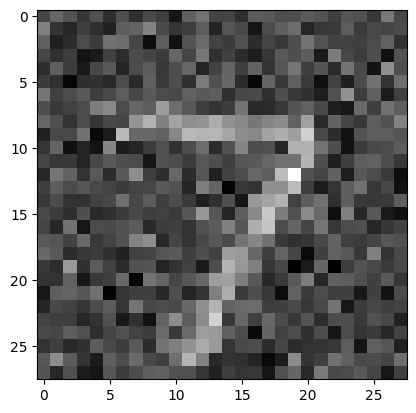

In [32]:
noise_level = 0.3
mnist_test_with_noise = inject_noise(mnist_te.data, noise_level)
__ = plt.imshow(mnist_test_with_noise[0].reshape(28, 28).to("cpu"), cmap="gray") # we start from a bidimensional image and convert to a one dimensional vector

We will now compute the hidden representations for the noisy images using the DBN. Then, we will use the read-out classifiers that we trained on the representations without noise to classify the noisy stimuli.

In [40]:
def get_accuracy_values_at_noise_level(noise_level):

  mnist_test_with_noise = inject_noise(mnist_te.data, noise_level)  # first, let's create noisy test images

  hidden_repr_1_noisy = get_kth_layer_repr(mnist_test_with_noise, 0, device)  # here we compute the DBN representations
  hidden_repr_2_noisy = get_kth_layer_repr(hidden_repr_1_noisy, 1, device)
  hidden_repr_3_noisy = get_kth_layer_repr(hidden_repr_2_noisy, 2, device)

  predictions_first_hidden_noisy = linear1(hidden_repr_1_noisy)  # here we use the previously-trained read-out classifiers
  predictions_second_hidden_noisy = linear2(hidden_repr_2_noisy)
  predictions_third_hidden_noisy = linear3(hidden_repr_3_noisy)

  accuracy_first_hidden = compute_accuracy(predictions_first_hidden_noisy, mnist_te.targets)
  accuracy_second_hidden = compute_accuracy(predictions_second_hidden_noisy, mnist_te.targets)
  accuracy_third_hidden = compute_accuracy(predictions_third_hidden_noisy, mnist_te.targets)

  ### TASK: repeat a similar process right above for the feed-forward model (NB: make sure you reshape the input data appropriately!)

#  (it's easier because we don't have to get the hidden activation )
#solution of prof:
  predictions_ffnn_noisy= ffnn(mnist_test_with_noise.reshape(10000,784))
  accuracy_ffnn=compute_accuracy(predictions_ffnn_noisy,mnist_te.targets)
  return accuracy_first_hidden, accuracy_second_hidden, accuracy_third_hidden, accuracy_ffnn

In [41]:
acc = get_accuracy_values_at_noise_level(0.3);
print("Accuracy of H1 read-out: %.3f" % acc[0])
print("Accuracy of H2 read-out: %.3f" % acc[1])
print("Accuracy of H3 read-out: %.3f" % acc[2])
print("Accuracy of FF network : %.3f" % acc[3])

Accuracy of H1 read-out: 0.906
Accuracy of H2 read-out: 0.922
Accuracy of H3 read-out: 0.937
Accuracy of FF network : 0.897


Let's create the psychometric curves for the DBN (at different levels of internal representations) and for the feed-forward network:

In [36]:
def plot_noise_robustness_curves(noise_levels):
  accuracy_values_first_hidden = []
  accuracy_values_second_hidden = []
  accuracy_values_third_hidden = []
  accuracy_values_ffnn = []

  for noise_level in noise_levels:
    acc = get_accuracy_values_at_noise_level(noise_level)
    accuracy_values_first_hidden.append(acc[0])
    accuracy_values_second_hidden.append(acc[1])
    accuracy_values_third_hidden.append(acc[2])
    accuracy_values_ffnn.append(acc[3])

  fig, ax = plt.subplots()
  ax.plot(range(len(noise_levels)), accuracy_values_first_hidden)
  ax.plot(range(len(noise_levels)), accuracy_values_second_hidden)
  ax.plot(range(len(noise_levels)), accuracy_values_third_hidden)
  ax.plot(range(len(noise_levels)), accuracy_values_ffnn)

  ax.set_title("Robustness to noise")
  ax.set_xlabel("Noise level (%)")
  ax.set_ylabel("Accuracy")
  plt.xticks(range(len(noise_levels)), [int(l*100) for l in noise_levels])
  plt.legend(["First hidden", "Second hidden", "Third hidden", "FFNN"])

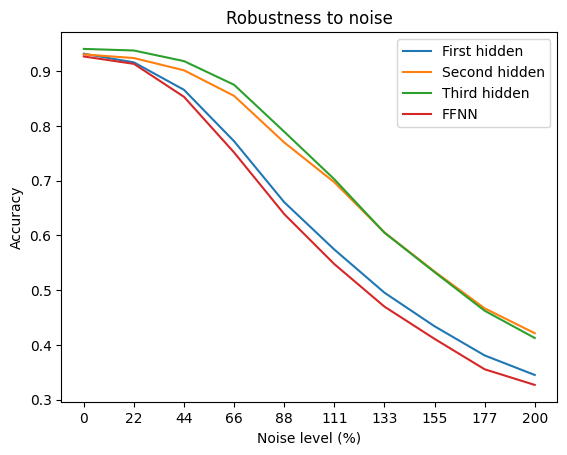

In [42]:
noise_levels = np.linspace(0,2,10) # we create loise nevel using this linear function
plot_noise_robustness_curves(noise_levels)
# the second hidden layer is actually pretty good, third is good until a certain amount of noise . third layer shows a big gap between fisrt hidden layer
#

# in the next lab, they use adversarial injection noise

## Reference paper
- [Testolin et al. (2017) - Letter perception emerges from unsupervised deep learning and recycling of natural image features](https://www.nature.com/articles/s41562-017-0186-2)